# 45.2 · Depth uncertainty and invalid pixels

CPU · Python 3.11–3.13 · seeded teaching experiment

[Open in Google Colab](https://colab.research.google.com/) — use the [ZIP setup workflow](../../docs/colab.md). No model or dataset downloads occur in this notebook.

## Learning Objectives

- Explain depth uncertainty and invalid pixels using the chapter's assumptions.
- Translate the worked equation into Python and inspect an implementation.
- Run, visualize and critique a reproducible experiment.

## Prerequisites

[31 · Semantic Segmentation](../../31-semantic-segmentation/README.md), [44 · 3D Computer Vision](../../44-3d-computer-vision/README.md)

Install the repository before opening this notebook: `python -m pip install -e ".[notebooks,deep,api]"`. The deep/API extras are needed only by chapters that use them.

## 1. Introduction

Depth is distance along a stated camera axis or ray; the convention must be declared. Stereo geometry can recover metric depth from calibration, while monocular learned depth often has scale ambiguity or domain-dependent calibration.

## 2. Intuition

Depth varies inversely with disparity, so the same pixel disparity error causes greater depth error for distant objects. First-order uncertainty propagates through the derivative of the depth formula. Evaluate only valid regions and report their coverage; excluding difficult pixels without reporting coverage can inflate apparent quality.

In [1]:
import inspect
import json
import platform
from importlib.metadata import version

import cv2
import numpy as np
from IPython.display import Code, display

from cvzero.course.runner import lab_function, run

CHAPTER = 45
LESSON = 1
SEED = 42
AMOUNT = 1.0
print(
    {
        "python": platform.python_version(),
        "numpy": version("numpy"),
        "opencv": cv2.__version__,
        "device": "cpu",
        "seed": SEED,
    }
)

{'python': '3.12.14', 'numpy': '2.3.5', 'opencv': '4.14.0', 'device': 'cpu', 'seed': 42}


## 3. Mathematical Foundation

$$
Z=fB/d
$$

Z is depth, f focal length in pixels, B baseline in meters and d disparity in pixels. With f=200 px, B=0.12 m and d=8 px, Z=3 m. Units cancel only when f and d share pixel units.

Read the symbols aloud, predict the numerical result, and only then execute the worked example.

## 4. Visual Explanation

The chapter preview shows an actual baseline run. Read every panel title before interpreting color or brightness; some panels show a mask, an error, or a matrix rather than a photograph.

![Measured chapter baseline](../assets/lab-preview.png)

## 5. Basic Implementation

This small calculation isolates the equation from the larger pipeline. Change one number and predict its effect before rerunning.

In [2]:
focal_px, baseline_m, disparity_px = 200.0, 0.12, 8.0
depth_m = focal_px * baseline_m / disparity_px
assert np.isclose(depth_m, 3)
print(depth_m)

3.0


## 6. OpenCV Implementation

The relevant library is selected by the problem: OpenCV for image operations and geometry, scikit-learn for classical learning, PyTorch for differentiable models, and FastAPI for service contracts. OpenCV handles image arrays where it is useful; it does not supply every advanced model.

The lab generates a known depth surface, converts it to disparity, adds measured pixel noise and recovers depth with invalid-value masking. It also visualizes first-order uncertainty.

The lab function below calls the actual implementation. Inspect its source to see preprocessing, fixed hyperparameters and reported metrics.

In [3]:
display(Code(inspect.getsource(lab_function(CHAPTER)), language="python"))
result = run(CHAPTER, lesson=LESSON, seed=SEED, amount=AMOUNT)
print(json.dumps(result.metrics, indent=2))
print(result.notes)

def depth(lesson=0, seed=42, amount=1.0):
    y, x = np.mgrid[:64, :96]
    true = 2 + x / 40 + y / 60
    focal, baseline = 200.0, 0.12
    rng = np.random.default_rng(seed)
    disparity = focal * baseline / true + rng.normal(0, 0.1 * amount, true.shape)
    if lesson == 2:
        disparity[20:30, 20:40] = 0
    estimate = disparity_to_depth(disparity, focal, baseline)
    valid = np.isfinite(estimate)
    uncertainty = focal * baseline / np.maximum(disparity, 1e-6) ** 2 * 0.1 * amount
    return Result(
        "45 · Metric depth and uncertainty",
        {
            "True Z (m)": true,
            "Disparity (px)": disparity,
            "Estimated Z (m)": estimate,
            "First-order uncertainty (m)": np.where(valid, uncertainty, np.nan),
        },
        metrics={
            "valid_fraction": float(valid.mean()),
            "valid_mae_m": float(np.abs(estimate[valid] - true[valid]).mean()),
        },
        notes="Stereo depth from known calibration; zero disparity is invalid. Monocular learned depth may have unknown scale, so it cannot silently be substituted into this formula as metric distance.",
    )

{
  "valid_fraction": 1.0,
  "valid_mae_m": 0.047938565970738166
}
Stereo depth from known calibration; zero disparity is invalid. Monocular learned depth may have unknown scale, so it cannot silently be substituted into this formula as metric distance.


## 7. From-Scratch Implementation

Read the following reusable reference implementation line by line. Identify input shapes, the main update or reduction, and the boundary/invalid-input policy. Its source lives in `src/cvzero/course/geometry.py`; notebooks reuse it so fixes apply everywhere. Optimized libraries are compared where matching behavior is meaningful.

In [4]:
from cvzero.course.geometry import disparity_to_depth

display(Code(inspect.getsource(disparity_to_depth), language="python"))

def disparity_to_depth(disparity, focal_px, baseline):
    """Z=fB/d. Invalid/nonpositive disparity returns NaN, not invented distance."""
    disparity = np.asarray(disparity, float)
    if focal_px <= 0 or baseline <= 0:
        raise ValueError("Focal length and baseline must be positive.")
    return np.divide(
        focal_px * baseline, disparity, out=np.full_like(disparity, np.nan), where=disparity > 0
    )

## 8. Experiment

Add the same disparity noise at 2 m and 6 m. Compare depth MAE and explain the nonlinear difference.

The run configuration is defined above. `lesson` selects the chapter experiment, `seed` fixes generated data or initialization, and `amount` controls the active experiment's perturbation when supported. Consult the displayed function before changing it: a fixed mathematical example may deliberately ignore a random seed or perturbation. Keep all other settings fixed when testing one hypothesis.

In [5]:
# A second independent seed checks sensitivity; fixed examples may remain identical.
repeat = run(CHAPTER, lesson=LESSON, seed=SEED + 1, amount=AMOUNT)
print(json.dumps({"baseline": result.metrics, "second_seed": repeat.metrics}, indent=2))

{
  "baseline": {
    "valid_fraction": 1.0,
    "valid_mae_m": 0.047938565970738166
  },
  "second_seed": {
    "valid_fraction": 1.0,
    "valid_mae_m": 0.0481799477682095
  }
}


## 9. Visualization

These figures are generated by the current run. The second plot uses the second seed. Compare the numerical report with the visible result; a single scalar rarely explains every failure.

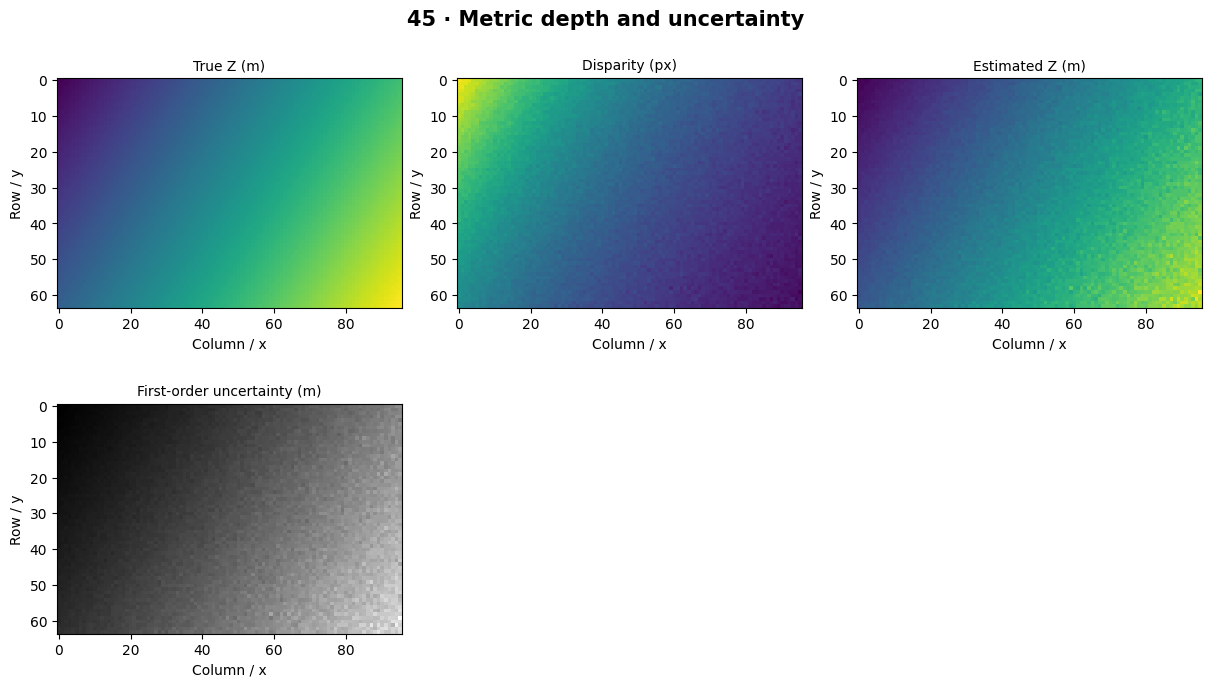

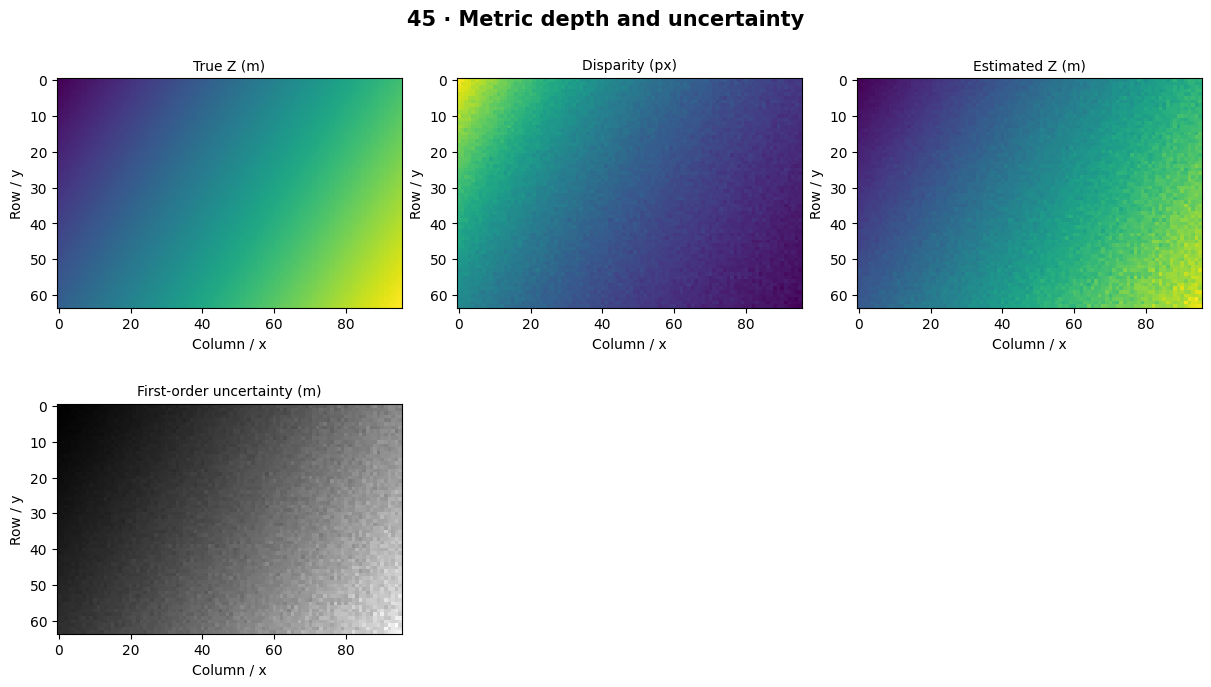

In [6]:
display(result.plot())
display(repeat.plot())

## 10. Real-World Application

The chapter mini project is **Depth Inspector**. Evaluate depth without pretending image estimates are measurements. Start with the generated data so expected geometry or labels are known, then use a separately documented real dataset. Do not transfer synthetic metrics to a real deployment claim.

## 11. Common Mistakes

A visually smooth depth map can be consistently wrong in scale. Depth Z and Euclidean range are different away from the optical axis.

Check shape, dtype, units, split and coordinate conventions before tuning an algorithm.

## 12. Exercises

- **Easy:** Reproduce the worked numerical example by hand and add a second case.
- **Medium:** Add the same disparity noise at 2 m and 6 m. Compare depth MAE and explain the nonlinear difference.
- **Hard:** Create a failure case for one assumption stated in this lesson and propose a measurable remedy.

## 13. Challenge

Build a depth report that includes valid fraction, MAE by distance range and an uncertainty overlay.

Write acceptance criteria before coding. No challenge solution is included beside the question.

## 14. Summary

Depth varies inversely with disparity, so the same pixel disparity error causes greater depth error for distant objects. First-order uncertainty propagates through the derivative of the depth formula. Evaluate only valid regions and report their coverage; excluding difficult pixels without reporting coverage can inflate apparent quality.

**Checkpoint:** explain the mechanism, implement a small case, modify one parameter, debug a failure and apply it to a new example. Record evidence for all five.

## 15. Next Step

Continue with **Monocular priors and evaluation** in this chapter.

[Primary reference](https://docs.opencv.org/4.x/dd/d53/tutorial_py_depthmap.html) · [Chapter exercises](../exercises/beginner.md) · [Mini project](../mini-project/README.md)